CUADERNO 2: ENTRENAMIENTO DEL MODELO DE TRIaje
Sistema de Apoyo al Triaje Hospitalario

CARGA DE DATOS PROCESADOS
✅ X_train shape: (24, 10)
✅ X_test shape: (6, 10)
✅ y_train shape: (24,)
✅ y_test shape: (6,)
✅ Features: 10
✅ Clases: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

ENTRENAMIENTO - MODELO BASE
Métricas del modelo base:
Accuracy: 0.6667
F1-Score (macro): 0.6333
F1-Score (weighted): 0.6111

OPTIMIZACIÓN DE HIPERPARÁMETROS
Realizando GridSearch con validación cruzada (5-fold)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✅ Mejor score CV (f1_macro): 0.6000

EVALUACIÓN DEL MODELO OPTIMIZADO
Métricas en conjunto de prueba:
Accuracy: 0.6667
Precision (macro): 0.6000
Recall (macro): 0.7000
F1-Score (macro): 0.6333
F1-Score (weighted): 0.6111

Reporte por clase:
              precision    recall  f1-score   support

  Nivel 1 -        

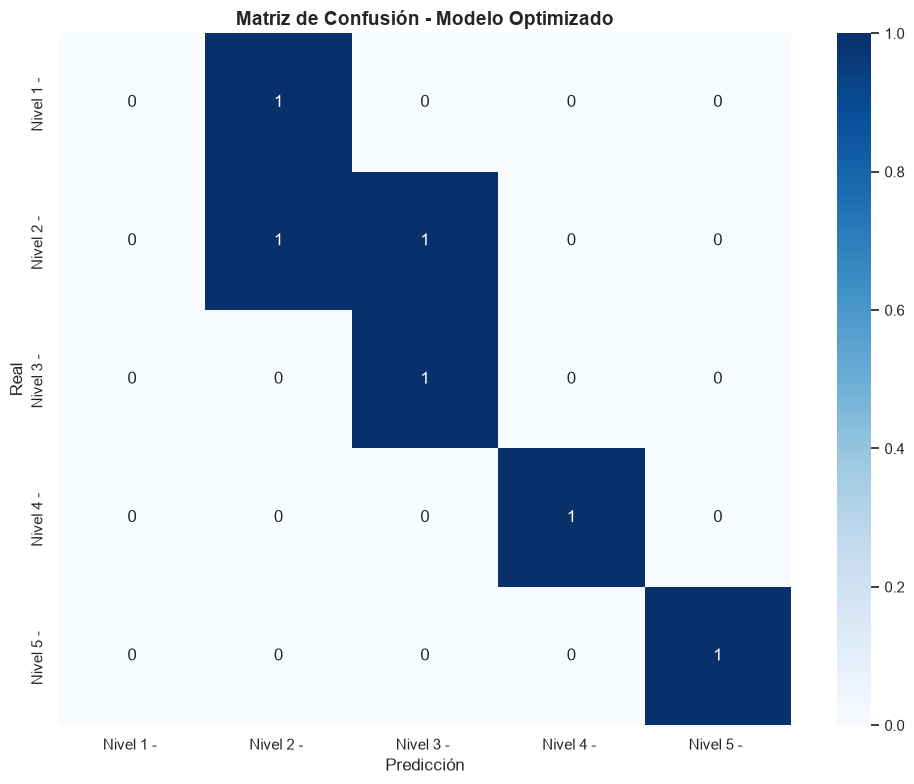

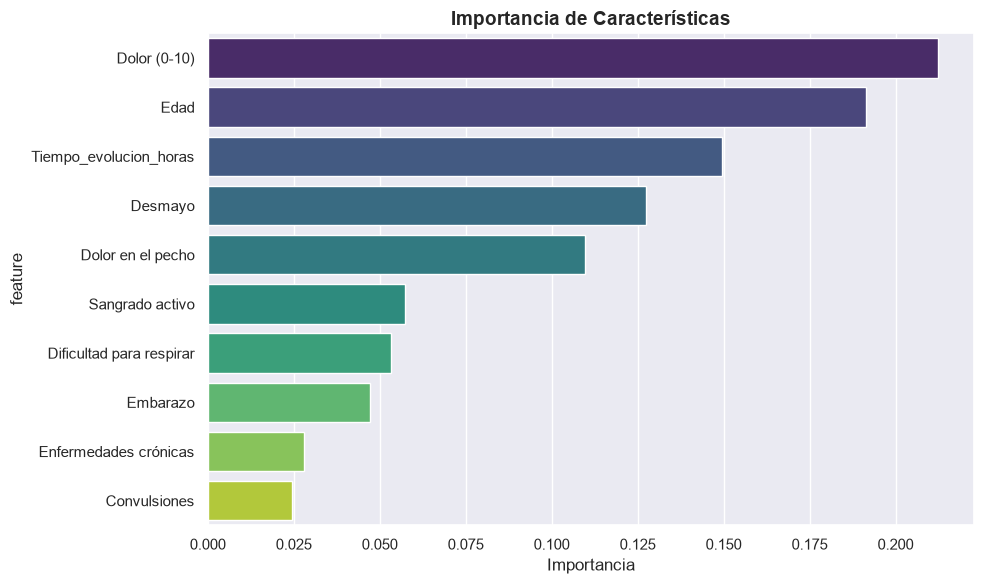


Importancia de features (top 5):
               feature  importance
          Dolor (0-10)    0.212197
                  Edad    0.191349
Tiempo_evolucion_horas    0.149490
               Desmayo    0.127422
     Dolor en el pecho    0.109562

VALIDACIÓN CRUZADA (5-fold)
Scores: [0.66666667 0.53333333 0.26666667 0.53333333 1.        ]
Media: 0.6000 (+/- 0.2385)

GUARDANDO MODELO
✅ Archivos guardados:
   - models/rf_triaje_model.pkl
   - models/model_metadata.pkl

RESUMEN FINAL - CUADERNO 2
Mejor modelo: RandomForestClassifier
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy en prueba: 0.6667
F1-Score macro: 0.6333
CV Score (media): 0.6000 (+/- 0.2385)

✅ Cuaderno 2 completado exitosamente.


In [ ]:
# ============================================
# CUADERNO 2: ENTRENAMIENTO DEL MODELO
# Sistema de Apoyo al Triaje Hospitalario
# ============================================

# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Crear directorios si no existen
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Configurar visualización
plt.style.use('default')
sns.set_theme()
sns.set_palette("husl")
%matplotlib inline

print("=" * 60)
print("CUADERNO 2: ENTRENAMIENTO DEL MODELO DE TRIaje")
print("Sistema de Apoyo al Triaje Hospitalario")
print("=" * 60)

# ============================================
# 2. CARGA DE DATOS PROCESADOS
# ============================================

print("\n" + "=" * 60)
print("CARGA DE DATOS PROCESADOS")
print("=" * 60)

# Verificar que los archivos existen
archivos_necesarios = [
    'data/X_train_scaled.csv',
    'data/X_test_scaled.csv',
    'data/y_train.csv',
    'data/y_test.csv',
    'models/features_list.pkl',
    'models/mapa_prioridad.pkl'
]

faltantes = [f for f in archivos_necesarios if not os.path.exists(f)]
if faltantes:
    print("⚠️ Faltan los siguientes archivos:")
    for f in faltantes:
        print(f"   - {f}")
    print("\nEjecuta primero el Cuaderno 1 para generar los datos.")
    raise FileNotFoundError("Archivos de datos no encontrados")

X_train = pd.read_csv('data/X_train_scaled.csv')
X_test = pd.read_csv('data/X_test_scaled.csv')
y_train = pd.read_csv('data/y_train.csv').values.ravel()
y_test = pd.read_csv('data/y_test.csv').values.ravel()

features = joblib.load('models/features_list.pkl')
mapa_prioridad = joblib.load('models/mapa_prioridad.pkl')

print(f"✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")
print(f"✅ y_train shape: {y_train.shape}")
print(f"✅ y_test shape: {y_test.shape}")
print(f"✅ Features: {len(features)}")
print(f"✅ Clases: {sorted(np.unique(y_train))}")

# ============================================
# 3. ENTRENAMIENTO CON RANDOM FOREST (BASE)
# ============================================

print("\n" + "=" * 60)
print("ENTRENAMIENTO - MODELO BASE")
print("=" * 60)

rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

print("Métricas del modelo base:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_base, average='weighted'):.4f}")

# ============================================
# 4. OPTIMIZACIÓN DE HIPERPARÁMETROS
# ============================================

print("\n" + "=" * 60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("=" * 60)

# Grid reducido para tiempos razonables
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Realizando GridSearch con validación cruzada (5-fold)...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"✅ Mejor score CV (f1_macro): {grid_search.best_score_:.4f}")

# Modelo optimizado
rf_optimized = grid_search.best_estimator_

# ============================================
# 5. EVALUACIÓN DEL MODELO OPTIMIZADO
# ============================================

print("\n" + "=" * 60)
print("EVALUACIÓN DEL MODELO OPTIMIZADO")
print("=" * 60)

y_pred = rf_optimized.predict(X_test)
y_pred_proba = rf_optimized.predict_proba(X_test)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("Métricas en conjunto de prueba:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")
print(f"F1-Score (weighted): {f1_weighted:.4f}")

# Reporte por clase
target_names = [f"Nivel {i} - {mapa_prioridad.get(i, '')}" for i in sorted(np.unique(y_train))]
print("\nReporte por clase:")
print(classification_report(y_test, y_pred, target_names=target_names))

# ============================================
# 6. MATRIZ DE CONFUSIÓN
# ============================================

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Matriz de Confusión - Modelo Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('results/matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 7. IMPORTANCIA DE FEATURES
# ============================================

plt.figure(figsize=(10, 6))
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_optimized.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Importancia de Características', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('results/importancia_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nImportancia de features (top 5):")
print(feature_importance.head(5).to_string(index=False))

# ============================================
# 8. VALIDACIÓN CRUZADA
# ============================================

cv_scores = cross_val_score(rf_optimized, X_train, y_train, cv=5, scoring='f1_macro')
print("\n" + "=" * 60)
print("VALIDACIÓN CRUZADA (5-fold)")
print("=" * 60)
print(f"Scores: {cv_scores}")
print(f"Media: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ============================================
# 9. GUARDAR MODELO Y METADATOS
# ============================================

print("\n" + "=" * 60)
print("GUARDANDO MODELO")
print("=" * 60)

joblib.dump(rf_optimized, 'models/rf_triaje_model.pkl')

model_metadata = {
    'model_type': 'RandomForestClassifier',
    'features': features,
    'classes': sorted(np.unique(y_train)),
    'n_classes': len(np.unique(y_train)),
    'mapa_prioridad': mapa_prioridad,
    'accuracy': accuracy,
    'f1_macro': f1_macro,
    'best_params': grid_search.best_params_,
    'cv_score_mean': cv_scores.mean(),
    'cv_score_std': cv_scores.std()
}

joblib.dump(model_metadata, 'models/model_metadata.pkl')

print("✅ Archivos guardados:")
print("   - models/rf_triaje_model.pkl")
print("   - models/model_metadata.pkl")

# ============================================
# 10. RESUMEN FINAL
# ============================================

print("\n" + "=" * 60)
print("RESUMEN FINAL - CUADERNO 2")
print("=" * 60)
print(f"Mejor modelo: RandomForestClassifier")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Accuracy en prueba: {accuracy:.4f}")
print(f"F1-Score macro: {f1_macro:.4f}")
print(f"CV Score (media): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("\n✅ Cuaderno 2 completado exitosamente.")